In [1]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# https://archive-beta.ics.uci.edu/dataset/502/online%2Bretail%2Bii?utm_source=chatgpt.com
df = pd.read_excel("./data/online_retail_II.xlsx")

## 1. Data cleaning

In [3]:
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB
None


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df = df.dropna(subset=["Customer ID"])

In [5]:
print(df["Customer ID"].nunique())
df.describe() # 4383 unique customer ids

4383


,Quantity,InvoiceDate,Price,Customer ID
count,417534.000000,417534,417534.000000,417534.000000
mean,12.758815,2010-07-01 01:12:19.787610,3.887547,15360.645478
min,-9360.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,2.000000,2010-03-26 11:26:00,1.250000,13983.000000
50%,4.000000,2010-07-08 19:12:00,1.950000,15311.000000
75%,12.000000,2010-10-14 14:08:00,3.750000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,101.220424,NaN,71.131797,1680.811316


### Define churn - inactivity in a specified period

In [105]:
cutoff_date = pd.to_datetime("2010-10-30")

In [106]:
df_filtered = df[df["InvoiceDate"] > cutoff_date]
print(df_filtered.shape)
print(df_filtered["Customer ID"].nunique())

(78978, 8)
1929


### create train dataframe with transations outside churn period

In [107]:
train_df = df[df["InvoiceDate"] <= cutoff_date]
print(train_df.shape)
print(train_df["Customer ID"].nunique())

(338556, 8)
4004


### define churn label

In [109]:
churn = train_df[['Customer ID']].drop_duplicates()
churn["churn"] = 1
unique_ids = df_filtered['Customer ID'].unique()
print(len(unique_ids))
churn.loc[churn['Customer ID'].isin(unique_ids), 'churn'] = 0
print(churn['churn'].sum(), churn.shape)
churn.head()

1929
2454 (4004, 2)


,Customer ID,churn
0,13085.0,1
12,13078.0,0
31,15362.0,1
54,18102.0,0
71,12682.0,0


4004 customers total, 2454 churned (60%/40% class split)

### 1.1 Negative quantily - returns / cancellations per customer

In [110]:
train_df[train_df["Quantity"] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [111]:
cancelled = train_df[train_df["Invoice"].astype(str).str.startswith("C")] # cancelled / returned orders -> invoice starts with C
cancelled["returns"] = train_df["Invoice"].astype(str).str.startswith("C").astype(int)
returns = cancelled.groupby("Customer ID", as_index=False)["returns"].sum().query("returns > 0")
print(returns.shape)
returns.head()

(1595, 2)


,Customer ID,returns
0,12346.0,13
1,12349.0,5
2,12359.0,4
3,12360.0,1
4,12380.0,2


In [112]:
noreturn_customers = train_df[~train_df['Customer ID'].isin(returns['Customer ID'])][['Customer ID']].drop_duplicates()
noreturn_customers["returns"] = 0
returns = pd.concat([returns, noreturn_customers], ignore_index=True)
returns.shape

(4004, 2)

### RFM

In [113]:
rfm_data = train_df.copy()
print(rfm_data.shape)
# drop returned orders
rfm_data = rfm_data[~rfm_data["Invoice"].astype(str).str.startswith("C")]
print(rfm_data.shape)
rfm_data["TotalPrice"] = rfm_data["Quantity"] * rfm_data["Price"]
rfm_data.head()

(338556, 8)
(330197, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


## RFM Features

In [114]:
rfm = rfm_data.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (cutoff_date - x.max()).days,
    "Invoice": "nunique",
    "TotalPrice": "sum"
}).rename(columns={
    "InvoiceDate": "Recency",
    "Invoice": "Frequency",
    "TotalPrice": "Monetary"
})
print(rfm.shape)
rfm.head()

(3933, 3)


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,123,11,372.86
12348.0,32,1,222.16
12349.0,1,3,2671.14
12353.0,2,1,317.76
12355.0,161,1,488.21


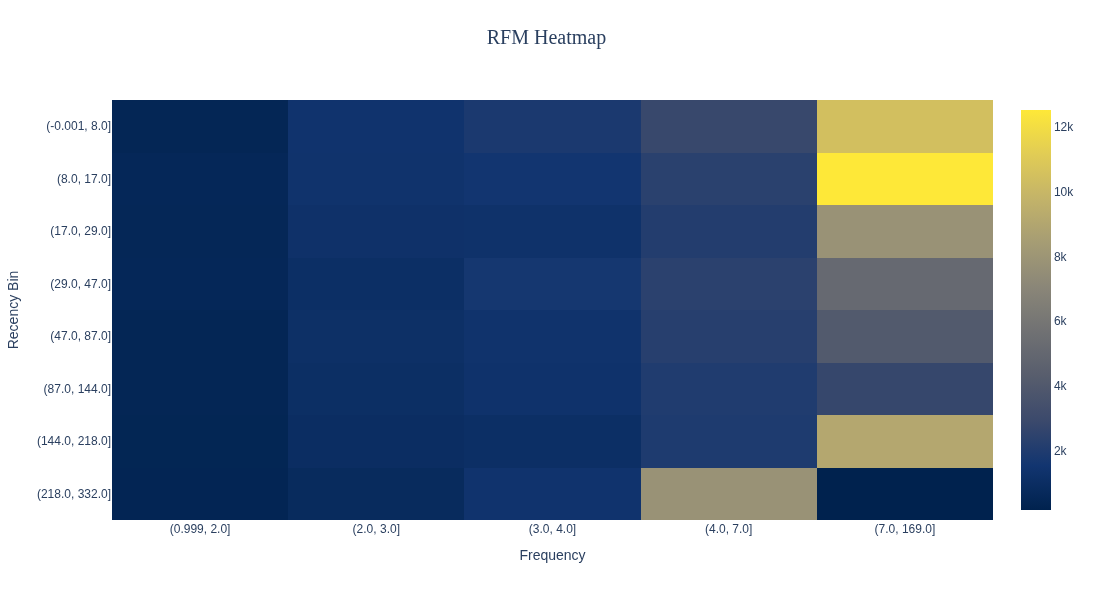

In [115]:
import plotly.graph_objects as go

features = rfm.copy().reset_index()
features['Recency_bin'] = pd.qcut(features['Recency'], 8, duplicates='drop')
features['Frequency_bin'] = pd.qcut(features['Frequency'], 8, duplicates='drop')

# Aggregate avg monetary and customer count
rfm_agg = features.groupby(['Recency_bin','Frequency_bin']).agg(
    avg_monetary=('Monetary','mean'),
    customer_count=('Customer ID','count')
).reset_index()

heatmap_matrix = rfm_agg.pivot(index='Recency_bin', columns='Frequency_bin', values='avg_monetary')
hover_matrix = rfm_agg.pivot(index='Recency_bin', columns='Frequency_bin', values='customer_count')

fig = go.Figure(data=go.Heatmap(
    z=heatmap_matrix.values,
    x=heatmap_matrix.columns.astype(str),
    y=heatmap_matrix.index.astype(str),
    colorscale='Cividis',
    reversescale=False,
    text=hover_matrix.values,
    hovertemplate=
        "<b>Recency Bin:</b> %{y}<br>"+
        "<b>Frequency Bin:</b> %{x}<br>"+
        "<b>Avg Monetary:</b> %{z:.2f}<br>"+
        "<b>Customer Count:</b> %{text}<extra></extra>"
))

fig.update_yaxes(autorange='reversed')

fig.update_layout(
    title={
        'text': "RFM Heatmap",
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(size=20, family="Arial Black")
    },
    xaxis_title="Frequency",
    yaxis_title="Recency Bin",
    template="plotly_white",
    width=700,
    height=600,
    margin=dict(l=80, r=80, t=100, b=80)
)
fig.show()

In [116]:
velocity_features = rfm_data.copy()
rfm_data["prev_purchase"] = rfm_data.groupby("Customer ID")["InvoiceDate"].shift(1)
rfm_data["days_between"] = (rfm_data["InvoiceDate"] - rfm_data["prev_purchase"]).dt.days
velocity_features = rfm_data.groupby("Customer ID")["days_between"].mean().rename("avg_days_between").reset_index()
# fill nan values (only one purchase) with recency and add feature indicating if customer mage multiple purchases
velocity_features['has_multiple_purchases'] = (velocity_features['avg_days_between'] > 1).astype(int)
# velocity_features['avg_days_between'] = velocity_features['avg_days_between'].fillna(rfm['Recency'])
velocity_features = velocity_features.merge(rfm, on="Customer ID", how="left")
# replace avg_days_between with recency for one purchase customers
velocity_features.loc[velocity_features['has_multiple_purchases'] == 0, 'avg_days_between'] = velocity_features['Recency']
velocity_features = velocity_features.merge(returns, on="Customer ID", how="left")
velocity_features.head()

,Customer ID,avg_days_between,has_multiple_purchases,Recency,Frequency,Monetary,returns
0,12346.0,6.000000,1,123,11,372.86,13
1,12348.0,32.000000,0,32,1,222.16,0
2,12349.0,1.782178,1,1,3,2671.14,5
3,12353.0,2.000000,0,2,1,317.76,0
4,12355.0,161.000000,0,161,1,488.21,0


## Churn

In [135]:
features = velocity_features.merge(churn, on="Customer ID", how="left")
print(features.shape)
features.head()

(3933, 8)


,Customer ID,avg_days_between,has_multiple_purchases,Recency,Frequency,Monetary,returns,churn
0,12346.0,6.000000,1,123,11,372.86,13,1
1,12348.0,32.000000,0,32,1,222.16,0,1
2,12349.0,1.782178,1,1,3,2671.14,5,1
3,12353.0,2.000000,0,2,1,317.76,0,1
4,12355.0,161.000000,0,161,1,488.21,0,1


In [136]:
features.info()
features["churn"].sum()

<class 'pandas.DataFrame'>
RangeIndex: 3933 entries, 0 to 3932
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3933 non-null   float64
 1   avg_days_between        3933 non-null   float64
 2   has_multiple_purchases  3933 non-null   int64  
 3   Recency                 3933 non-null   int64  
 4   Frequency               3933 non-null   int64  
 5   Monetary                3933 non-null   float64
 6   returns                 3933 non-null   int64  
 7   churn                   3933 non-null   int64  
dtypes: float64(3), int64(5)
memory usage: 245.9 KB


np.int64(2388)

In [179]:
features.to_csv("features.csv", index=False)

### feature correlation matrix for visualization purposes, typically not an issue for tree-based ensemble methods as XGBoost

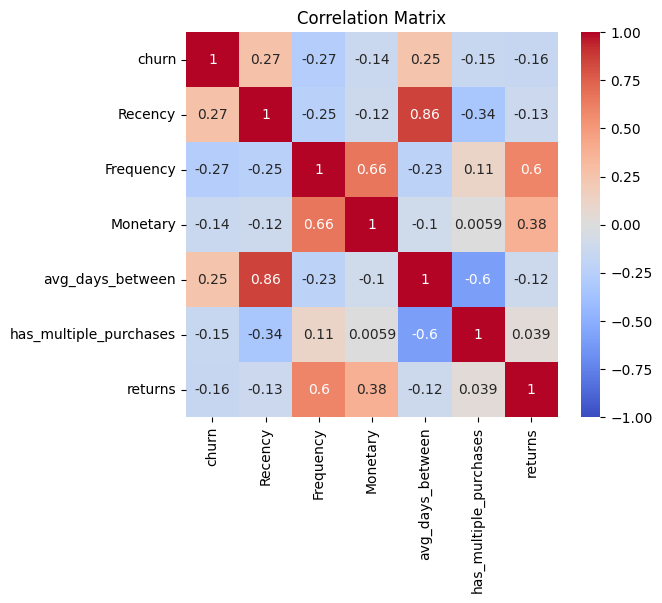

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric features
numeric_features = ['churn','Recency','Frequency','Monetary','avg_days_between', 'has_multiple_purchases', 'returns']

# Compute correlation matrix
corr_matrix = features[numeric_features].corr()

# Visualize
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

In [125]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Features to test
X = features[numeric_features].copy()
X = X.dropna(axis=0, how="any")

# Add constant for VIF calculation
X['intercept'] = 1
# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                  feature       VIF
0                   churn  1.135076
1                 Recency  4.646244
2               Frequency  2.567887
3                Monetary  1.802982
4        avg_days_between  6.282161
5  has_multiple_purchases  1.908947
6                 returns  1.568804
7               intercept  6.809245


In [158]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import xgboost as xgb

In [144]:
X = features.drop(columns=['churn', 'Customer ID'])
y = features['churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [156]:
model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

/home/agnieszka/PyCharmMiscProject/CLV/clv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:39:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [159]:
y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred, target_names=['Not Churn', 'Churn'])
print(report)

              precision    recall  f1-score   support

   Not Churn       0.62      0.52      0.56       309
       Churn       0.72      0.79      0.75       478

    accuracy                           0.68       787
   macro avg       0.67      0.66      0.66       787
weighted avg       0.68      0.68      0.68       787



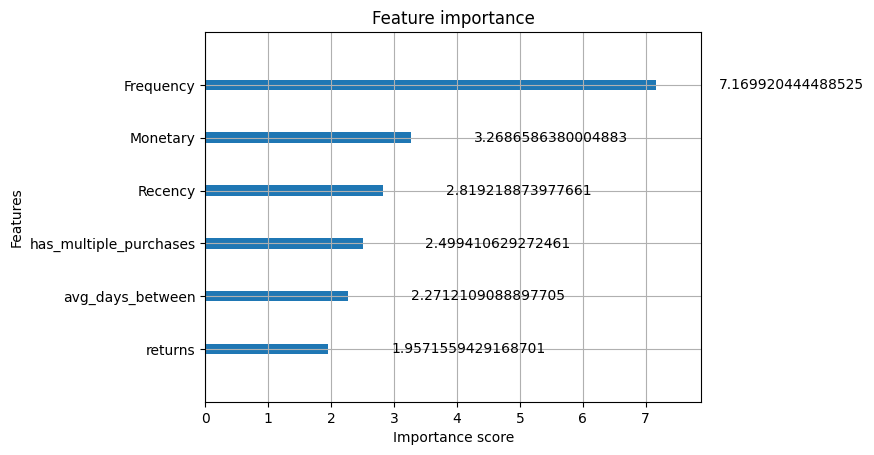

In [155]:
import matplotlib.pyplot as plt

xgb.plot_importance(model, max_num_features=10, importance_type='gain')
plt.show()

## hyperparameter tuning with optuna

In [173]:
import optuna
import xgboost as xgb
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum(),
        "eval_metric": "logloss"
    }

    model = XGBClassifier(**params)


    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_idx, valid_idx in cv.split(X_train, y_train):
        X_train_s, X_valid_s = X.iloc[train_idx], X.iloc[valid_idx]
        y_train_s, y_valid_s = y.iloc[train_idx], y.iloc[valid_idx]

        model.fit(X_train_s, y_train_s)

        proba = model.predict_proba(X_valid_s)[:, 1]

        # 👉 use probability-based metric
        score = roc_auc_score(y_valid_s, proba)
        scores.append(score)

    return np.mean(scores)


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)
print("Best Params:", study.best_params)
print("Best Recall:", study.best_value)

[I 2026-03-23 11:31:39,711] A new study created in memory with name: no-name-fb666551-0c2c-48ca-8516-1a1ef5c09d9e
[I 2026-03-23 11:31:40,057] Trial 0 finished with value: 0.7302536613086914 and parameters: {'n_estimators': 320, 'learning_rate': 0.05624125054619761, 'max_depth': 5, 'subsample': 0.5862217700414918, 'colsample_bytree': 0.6061440389985484, 'min_child_weight': 1, 'gamma': 4.63533522652411, 'reg_alpha': 4.560748397916416, 'reg_lambda': 1.1398699819873155}. Best is trial 0 with value: 0.7302536613086914.
[I 2026-03-23 11:31:40,491] Trial 1 finished with value: 0.7300671411113349 and parameters: {'n_estimators': 412, 'learning_rate': 0.13999261806786353, 'max_depth': 10, 'subsample': 0.8535061378640777, 'colsample_bytree': 0.5864448474775001, 'min_child_weight': 1, 'gamma': 1.5318556248901027, 'reg_alpha': 2.1328506946978414, 'reg_lambda': 3.7082215723765803}. Best is trial 0 with value: 0.7302536613086914.
[I 2026-03-23 11:31:41,015] Trial 2 finished with value: 0.72151239305

Best Params: {'n_estimators': 600, 'learning_rate': 0.010276792672319913, 'max_depth': 8, 'subsample': 0.5419608326053842, 'colsample_bytree': 0.8097474046196425, 'min_child_weight': 5, 'gamma': 2.217885017952656, 'reg_alpha': 2.4294409084377, 'reg_lambda': 3.1356875220115104}
Best Recall: 0.7321205969227335


## optimize threshold for recall
In churn prediction, recall is usually the most important. Churn prediction is asymmetric in cost:

False Negative (FN): model predicts that customer will not churn, but they actually leave → missed oportunity.

False Positive (FP): model predicts a customer will churn, but they stay → resources spent unnececary.

FN usually costs more than FP.

In [177]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Add the scale_pos_weight and fixed params to the best ones from Optuna
best_params = study.best_params
best_params.update({
    "random_state": 42,
    "n_jobs": -1,
    "scale_pos_weight": scale_pos_weight,
    "eval_metric": "logloss"
})

# Create model from best params
xgb = XGBClassifier(**best_params)
xgb.fit(X_train, y_train)
proba = xgb.predict_proba(X_test)[:, 1]

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Thresh  Prec_1  Rec_1   F1_1    
0.25    0.668   0.950   0.784   
0.3     0.680   0.937   0.788   
0.35    0.692   0.900   0.783   
0.4     0.708   0.889   0.788   
0.45    0.725   0.820   0.769   
0.5     0.746   0.738   0.742   


Thireshold 0.3 seems as good options:

Recall: 0.937 ✅ 

Precision: 0.680 (medium — some not churners are flagged)